# Customer Segmentation using K-Means Clustering

In this notebook, we apply K-Means clustering on the engineered RFM features to segment customers into meaningful groups. The clusters will help identify customers with different purchasing behaviors and support business decisions such as customer retention, personalized marketing, and loyalty programs.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score




## Load Engineered RFM Features

The scaled RFM features generated in the previous notebook are loaded. Scaling ensures that Recency, Frequency, and Monetary contribute equally during distance calculations because K-Means relies on Euclidean distance.

In [4]:
rfm_scaled = pd.read_csv(
    "C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed\\rfm_features.csv",
    index_col=0
)

rfm_original = pd.read_csv(
    "C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed\\rfm_original.csv",
    index_col=0
)

In [5]:
rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.966262,1.613017,-0.534787
12347.0,-1.900165,-0.394693,0.452542
12348.0,0.355000,-0.981910,-0.937590
12349.0,-0.055302,0.021945,1.000535
12351.0,-1.054928,-0.981910,-0.701598


In [6]:
rfm_original.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [7]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

"K-Means requires the number of clusters (k) to be specified beforehand. Since we don't know the optimal value in advance, we use techniques such as the Elbow Method, Silhouette Score, and Davies-Bouldin Index to identify a suitable number of clusters."

In [8]:
print(wcss)

[12936.000000000002, 6605.321861710037, 4973.786383144799, 3977.4009771126975, 3347.934571710155, 2925.016500068508, 2612.141750181937, 2396.967958853253, 2212.562861980611, 2042.6009031849808]


## Determine the Optimal Number of Clusters using the Elbow Method

K-Means requires the number of clusters (K) to be specified before training. Since the optimal value is unknown, the Elbow Method is used.

The method calculates the Within-Cluster Sum of Squares (WCSS) for different values of K.

WCSS measures the total squared distance between data points and their assigned centroid.

As K increases, WCSS always decreases because clusters become smaller.

The optimal K is selected at the point where adding more clusters results in only a small improvement. This point is known as the "Elbow".

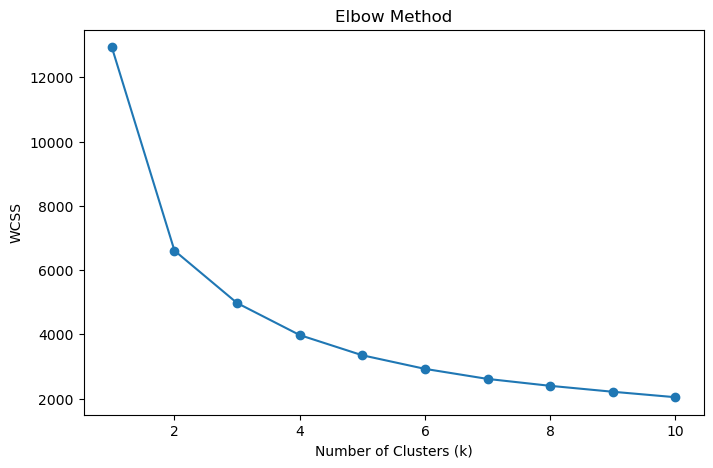

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")



plt.savefig("C:\\Users\\sonim\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")

plt.show()


### Observation

The elbow appears around **K = 4**.

After four clusters, the decrease in WCSS becomes gradual, indicating diminishing returns from adding more clusters.

## Evaluate Cluster Separation using the Silhouette Score

The Silhouette Score evaluates how well the clusters are separated.

For every customer, it compares:

- The average distance to customers within the same cluster.
- The average distance to customers in the nearest neighboring cluster.

A higher Silhouette Score indicates:

- High similarity within a cluster.
- Large separation between different clusters.

The score ranges from -1 to 1.

A value close to 1 represents well-separated clusters, whereas values near 0 indicate overlapping clusters.

In [10]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

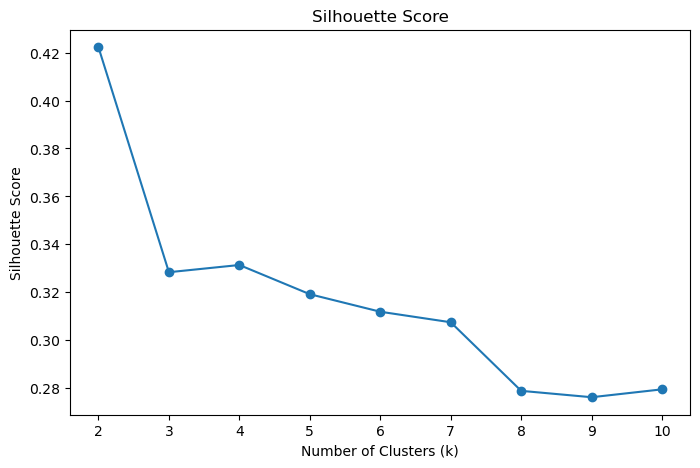

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker="o")

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")


plt.savefig("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")


plt.show()

### Observation

The highest Silhouette Score is observed at **K = 2**, indicating that two clusters provide the strongest statistical separation.

However, customer segmentation also requires meaningful business interpretation. Therefore, additional evaluation metrics are considered before selecting the final number of clusters.

## Evaluate Cluster Compactness using the Davies-Bouldin Index

The Davies-Bouldin Index measures the similarity between clusters.

It considers:

- Compactness within each cluster.
- Separation between different clusters.

Unlike the Silhouette Score, a **lower** Davies-Bouldin Index indicates better clustering.

Lower values suggest that clusters are compact and well separated.

In [12]:
db_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = davies_bouldin_score(rfm_scaled, labels)

    db_scores.append(score)

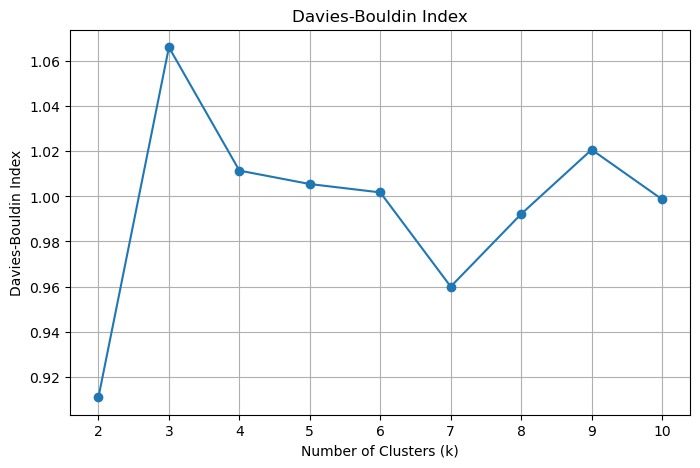

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), db_scores, marker="o")

plt.title("Davies-Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")

plt.grid(True)
plt.savefig("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")


plt.show()

### Observation

The Davies-Bouldin Index reaches its lowest value around **K = 2**.

Although this suggests statistically compact clusters, business requirements often benefit from more detailed customer segmentation. Therefore, the final decision considers both evaluation metrics and practical business interpretation.

## Final Selection of Number of Clusters

Three evaluation techniques were used:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index

The Elbow Method suggested **K = 4**, while the Silhouette Score and Davies-Bouldin Index favored **K = 2**.

For this project, **K = 4** was selected because it provides richer and more actionable customer segments such as Champions, Loyal Customers, Potential Customers, and Lost Customers. These segments are more useful for business decision-making than only two broad customer groups.

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_scaled["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,0.966262,1.613017,-0.534787,3
12347.0,-1.900165,-0.394693,0.452542,0
12348.0,0.355000,-0.981910,-0.937590,2
12349.0,-0.055302,0.021945,1.000535,3
12351.0,-1.054928,-0.981910,-0.701598,0


## Train the K-Means Model

The K-Means algorithm is trained using the scaled RFM features.

Each customer is assigned to the nearest centroid based on Euclidean distance.

The algorithm iteratively updates the centroid positions until the cluster assignments stabilize.

## Cluster Distribution

The number of customers in each cluster is calculated to understand how customers are distributed among the identified segments.

A balanced distribution indicates that the clustering algorithm has successfully identified meaningful customer groups without creating extremely small or extremely large clusters.

In [15]:
rfm_scaled["Cluster"].value_counts().sort_index()

Cluster
0     945
1     778
2    1378
3    1211
Name: count, dtype: int64

In [16]:
rfm_scaled["Cluster"].value_counts()

Cluster
2    1378
3    1211
0     945
1     778
Name: count, dtype: int64

In [17]:
rfm_original["Cluster"] = rfm_scaled["Cluster"]

In [18]:
cluster_profile = (
    rfm_original
    .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,23.947090,1.972487,532.078583
1,13.827763,13.556555,7381.581077
2,190.569666,1.298984,305.661388
3,80.214699,4.138728,1759.990102


In [19]:
cluster_names = {
    0: "Potential Customers",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

rfm_original["Segment"] = rfm_original["Cluster"].map(cluster_names)

## Customer Profiling

The cluster labels are mapped back to the original RFM values.

Business interpretation should always use the original values because scaled values are intended only for model training.

The average Recency, Frequency, and Monetary values of each cluster help identify customer behavior and assign meaningful business labels.

In [20]:
print(cluster_names)

{0: 'Potential Customers', 1: 'Champions', 2: 'Lost Customers', 3: 'Loyal Customers'}


## Visualize Customer Segments using PCA

Principal Component Analysis (PCA) reduces the three RFM dimensions into two principal components.

Although some information is lost during dimensionality reduction, PCA preserves most of the variance and allows the customer clusters to be visualized in a two-dimensional space.

In [21]:
from sklearn.decomposition import PCA

In [22]:
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(rfm_scaled.drop(columns="Cluster"))

In [23]:
pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm_scaled["Cluster"].values

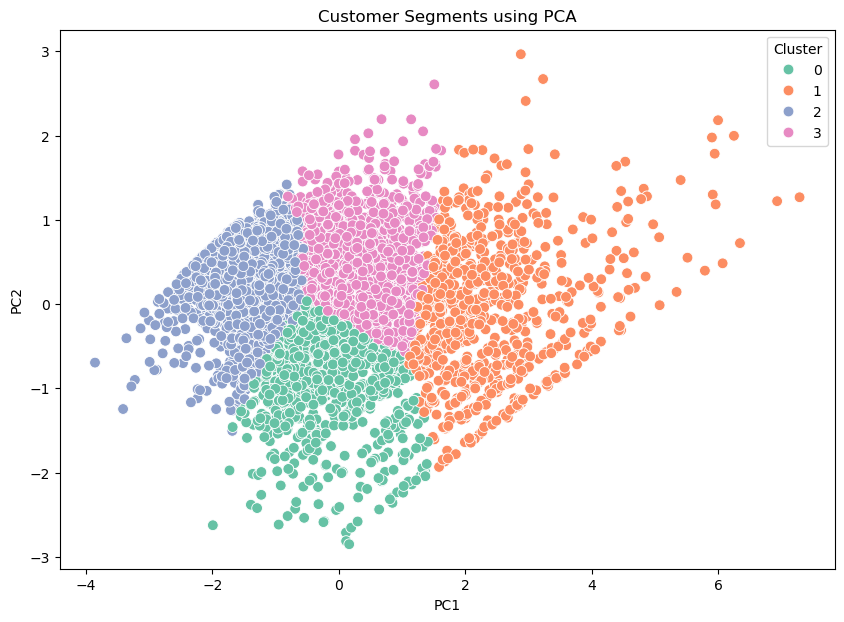

In [34]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Segments using PCA")
plt.savefig("C:\\Users\\sonim\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")

plt.show()

PCA reduces the three-dimensional RFM feature space into two principal components while preserving most of the variation in the data. This visualization helps understand how well the K-Means algorithm separated customer groups.

## Cluster Comparison

A heatmap is used to compare the average RFM values across customer segments.

This visualization makes it easier to identify high-value customers, inactive customers, and moderate customer groups.

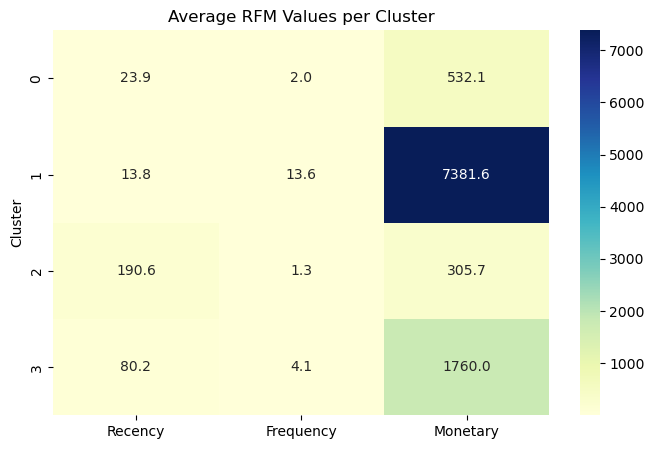

In [35]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average RFM Values per Cluster")

plt.savefig("C:\\Users\\sonim\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
cluster_names = {
    0: "Potential Customers",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

rfm_original["Segment"] = rfm_original["Cluster"].map(cluster_names)

In [27]:
rfm_original.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,3,Loyal Customers
12347.0,3,2,1323.32,0,Potential Customers
12348.0,74,1,222.16,2,Lost Customers
12349.0,43,3,2671.14,3,Loyal Customers
12351.0,11,1,300.93,0,Potential Customers


In [28]:
rfm_original["Segment"].value_counts()

Segment
Lost Customers         1378
Loyal Customers        1211
Potential Customers     945
Champions               778
Name: count, dtype: int64

## Business Recommendations

The identified customer segments can be targeted with different business strategies.

- Champions should receive exclusive rewards and loyalty benefits.
- Loyal Customers can be encouraged through cross-selling and personalized offers.
- Potential Customers should receive promotions that encourage repeat purchases.
- Lost Customers can be targeted through re-engagement campaigns and special discounts.

Customer Segment Insights

🏆 Champions
Recently purchased
Purchase frequently
Highest spending

Recommendation

VIP rewards
Loyalty programs
Exclusive product launches

❤️ Loyal Customers
Regular buyers
Moderate spending

Recommendation

Cross-selling
Upselling
Personalized recommendations

🌱 Potential Customers
Purchased recently
Low purchase frequency

Recommendation

Welcome discounts
Email campaigns
Encourage repeat purchases

😢 Lost Customers
Long time since last purchase
Low spending
Rare purchases

Recommendation

Win-back campaigns
Coupons
Re-engagement emails

# Executive Summary

This project segmented 4,312 customers using RFM analysis and K-Means clustering.

The workflow included:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering using RFM
- Log Transformation
- Feature Scaling
- K-Means Clustering
- Cluster Evaluation using Elbow Method, Silhouette Score and Davies-Bouldin Index
- PCA Visualization
- Business Interpretation

Four customer segments were identified:

1. Champions
2. Loyal Customers
3. Potential Customers
4. Lost Customers

These customer segments can be used by businesses to design personalized marketing campaigns, improve customer retention, and maximize revenue.

In [29]:
import os
print(os.getcwd())

c:\Users\sonim\Desktop\CUSTOMER SEGMENTATION\NOTEBOOKS


In [30]:
rfm = pd.read_csv(
    "C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed\\customer_segments.csv",
    index_col=0
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,3,Loyal Customers
12347.0,3,2,1323.32,0,Potential Customers
12348.0,74,1,222.16,2,Lost Customers
12349.0,43,3,2671.14,3,Loyal Customers
12351.0,11,1,300.93,0,Potential Customers
